# Using Keras to load the dataset

In [56]:
import tensorflow as tf 
import numpy as np

In [4]:
fashion_mnist = tf.keras.datasets.fashion_mnist 
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 5us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [6]:
print(X_train_full.shape)
X_train_full.dtype

(60000, 28, 28)


dtype('uint8')

In [8]:
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0 
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

In [9]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat","Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [12]:
print(class_names[y_train[0]])

Coat


# Building a Classification MLP using the Sequential API

# Creating the model using the Sequential API

In [26]:
import keras as keras
model = keras.models.Sequential() 
model.add(keras.layers.Flatten(input_shape=[28, 28])) 
model.add(keras.layers.Dense(300, activation="relu")) 
model.add(keras.layers.Dense(100, activation="relu")) 
model.add(keras.layers.Dense(10, activation="softmax"))

C:\Users\Syfer\.conda\envs\ds-ml\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
model = keras.models.Sequential([ 
keras.layers.Flatten(input_shape=[28, 28]), 
keras.layers.Dense(300, activation="relu"), 
keras.layers.Dense(100, activation="relu"), 
keras.layers.Dense(10, activation="softmax") 
])

In [28]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.layers

[<Flatten name=flatten_4, built=True>,
 <Dense name=dense_12, built=True>,
 <Dense name=dense_13, built=True>,
 <Dense name=dense_14, built=True>]

In [31]:
hidden1 = model.layers[1]
hidden1.name

'dense_12'

In [33]:
weights, biases = hidden1.get_weights() 
weights

array([[ 0.07265739, -0.00767476, -0.06565619, ..., -0.06511723,
        -0.04092556,  0.00260229],
       [-0.07070857, -0.0486282 ,  0.03431134, ..., -0.0178237 ,
         0.0446032 , -0.00766806],
       [-0.04482664, -0.06723902, -0.01376028, ..., -0.04519007,
        -0.02734411,  0.05162202],
       ...,
       [-0.04417698, -0.07245544,  0.03631547, ...,  0.02909675,
         0.03557309,  0.04365252],
       [-0.01930836, -0.02981794, -0.04741608, ..., -0.00148375,
        -0.04759419,  0.0555191 ],
       [ 0.06232587, -0.03079572,  0.07409531, ...,  0.05724739,
        -0.03995208, -0.0043482 ]], shape=(784, 300), dtype=float32)

In [34]:
weights.shape

(784, 300)

In [35]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [36]:
biases.shape

(300,)

In [37]:
model.compile(loss="sparse_categorical_crossentropy", 
optimizer="sgd", 
metrics=["accuracy"])

In [48]:
history = model.fit(X_train, y_train, epochs=30,validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9214 - loss: 0.2173 - val_accuracy: 0.8946 - val_loss: 0.2908
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9232 - loss: 0.2139 - val_accuracy: 0.8888 - val_loss: 0.3140
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9238 - loss: 0.2099 - val_accuracy: 0.8970 - val_loss: 0.2908
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9251 - loss: 0.2075 - val_accuracy: 0.8932 - val_loss: 0.3010
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9261 - loss: 0.2037 - val_accuracy: 0.8946 - val_loss: 0.3043
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9281 - loss: 0.2010 - val_accuracy: 0.8962 - val_loss: 0.2924
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9297 - loss: 0.1962 - val_accuracy: 0.8894 - val_loss: 0.3025
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9304 - loss

In [49]:
history.history

{'accuracy': [0.9214000105857849,
  0.923163652420044,
  0.9238181710243225,
  0.9250727295875549,
  0.9260727167129517,
  0.9280727505683899,
  0.9296908974647522,
  0.930363655090332,
  0.9310908913612366,
  0.9319272637367249,
  0.9334545731544495,
  0.9347454309463501,
  0.9359090924263,
  0.9361090660095215,
  0.9373090863227844,
  0.9387636184692383,
  0.9403818249702454,
  0.9403272867202759,
  0.9418727159500122,
  0.9417636394500732,
  0.9429090619087219,
  0.9450545310974121,
  0.9451636075973511,
  0.9475091099739075,
  0.9471636414527893,
  0.9487272500991821,
  0.9492363929748535,
  0.9498909115791321,
  0.9507272839546204,
  0.9513818025588989],
 'loss': [0.21730414032936096,
  0.2138778269290924,
  0.20988620817661285,
  0.2075004130601883,
  0.2036675214767456,
  0.2009725272655487,
  0.1961873173713684,
  0.1941596418619156,
  0.19125203788280487,
  0.18888525664806366,
  0.1856374591588974,
  0.18187521398067474,
  0.1785830557346344,
  0.17652542889118195,
  0.174225

In [50]:
history.params

{'verbose': 'auto', 'epochs': 30, 'steps': 1719}

In [51]:
history.epoch

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29]

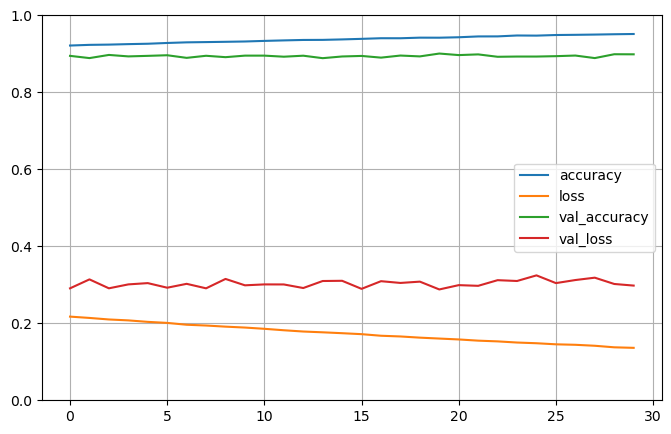

In [52]:
import pandas as pd 
import matplotlib.pyplot as plt 
pd.DataFrame(history.history).plot(figsize=(8, 5)) 
plt.grid(True) 
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1] 
plt.show()

# Using the model to mae predictions

In [ ]:
X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

In [ ]:
y_pred = model.predict_classes(X_new)
print(y_pred)

In [57]:
np.array(class_names)[y_pred]

NameError: name 'y_pred' is not defined

In [ ]:
y_new = y_test[:3]
y_new